In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("merged_fraud_dataset.csv",low_memory=False)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (57661, 45)


,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,...,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location
0,CC00011340,2025-07-15 19:54:24,C002995,visa,55.82,travel,uae,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CC00007384,2025-07-08 14:57:48,C003084,mastercard,85.33,travel,uae,atm,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CC00002213,2025-05-02 20:09:53,C003082,amex,76.06,entertainment,united states,website,other,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC00009658,2025-01-12 15:39:05,C002467,rupay,72.56,travel,united states,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CC00009328,2025-07-31 05:04:38,C001852,rupay,257.07,fuel,uae,pos,android,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"],errors="coerce")
print("Invalid or missing dates:", df["transaction_date"].isnull().sum())

Invalid or missing dates: 0


In [4]:
df["is_fraud"] = df["is_fraud"].replace({"Yes": 1,"No": 0,"True": 1,"False": 0})
df["is_fraud"] = pd.to_numeric(df["is_fraud"],errors="coerce").fillna(0).astype(int)
df["is_fraud"].value_counts()

is_fraud
0    56663
1      998
Name: count, dtype: int64

In [5]:
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.month_name()
df["day_name"] = df["transaction_date"].dt.day_name()

df["transaction_hour"] = pd.to_numeric(df["transaction_hour"],errors="coerce")
df["transaction_hour"] = df["transaction_hour"].fillna(df["transaction_date"].dt.hour)
df.head()

,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,...,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location,year,month,month_name,day_name
0,CC00011340,2025-07-15 19:54:24,C002995,visa,55.82,travel,uae,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2025,7,July,Tuesday
1,CC00007384,2025-07-08 14:57:48,C003084,mastercard,85.33,travel,uae,atm,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2025,7,July,Tuesday
2,CC00002213,2025-05-02 20:09:53,C003082,amex,76.06,entertainment,united states,website,other,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,May,Friday
3,CC00009658,2025-01-12 15:39:05,C002467,rupay,72.56,travel,united states,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2025,1,January,Sunday
4,CC00009328,2025-07-31 05:04:38,C001852,rupay,257.07,fuel,uae,pos,android,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2025,7,July,Thursday


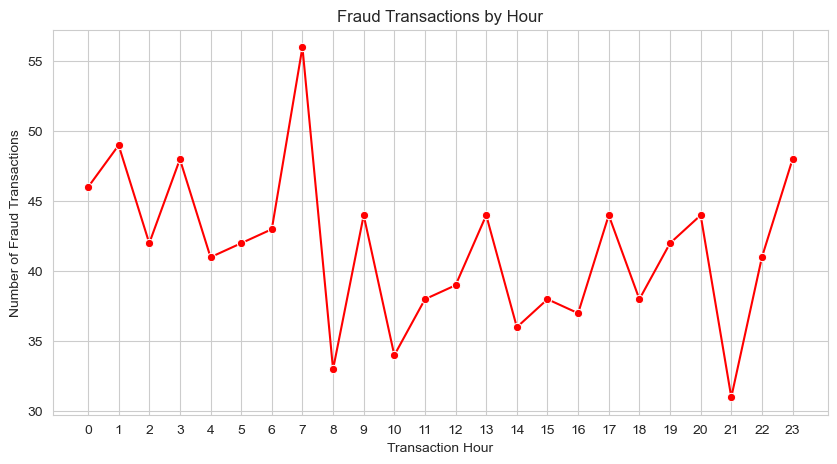

In [6]:
hourly_fraud = (df.groupby("transaction_hour")["is_fraud"].sum().reset_index())

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_fraud,x="transaction_hour",y="is_fraud",marker="o",color="red")
plt.title("Fraud Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(range(0, 24))
plt.show()

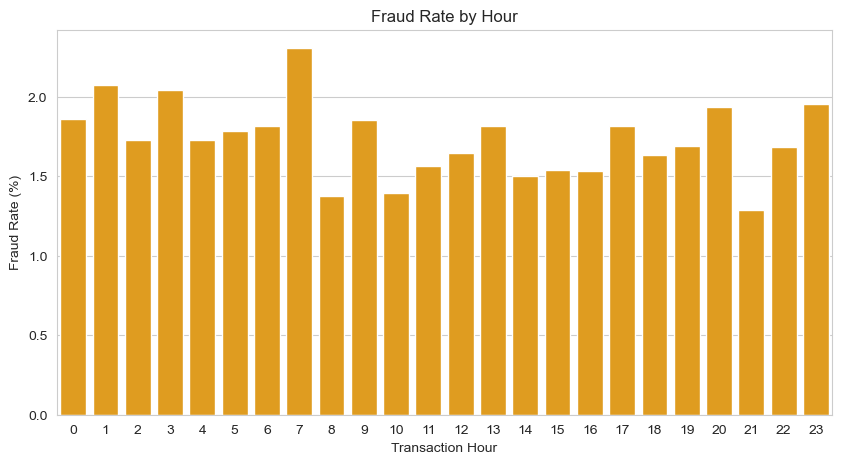

In [7]:
hourly_rate = (df.groupby("transaction_hour")["is_fraud"].mean().mul(100).reset_index(name="fraud_rate"))

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_rate,x="transaction_hour",y="fraud_rate",color="orange")
plt.title("Fraud Rate by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.show()

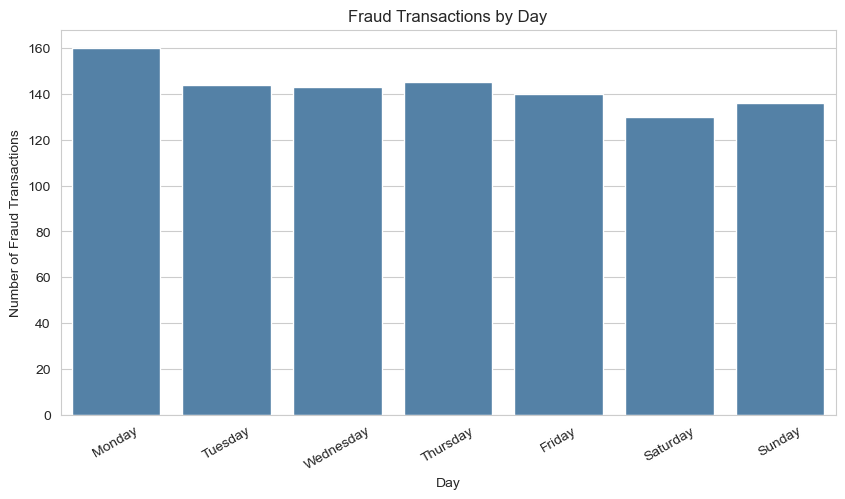

In [8]:
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
daily_fraud = (df.groupby("day_name")["is_fraud"].sum().reindex(day_order).reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_fraud,x="day_name",y="is_fraud",color="steelblue")
plt.title("Fraud Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=30)
plt.show()

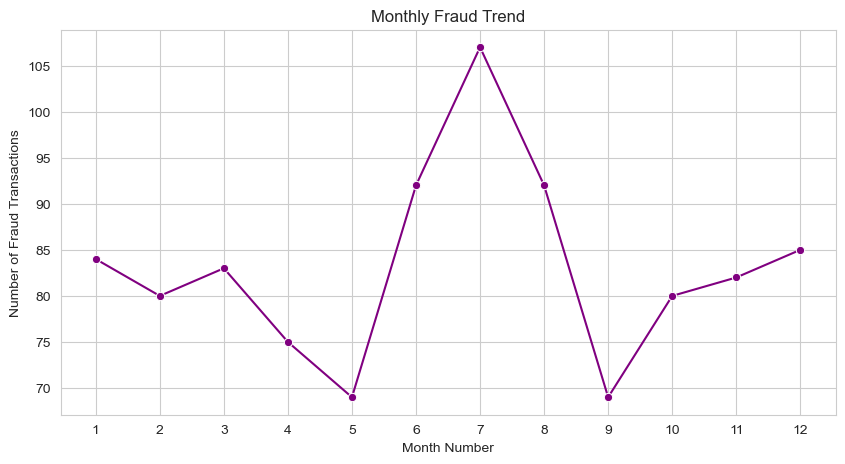

In [9]:
monthly_fraud = (df.groupby("month")["is_fraud"].sum().reset_index())

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_fraud,x="month",y="is_fraud",marker="o",color="purple")
plt.title("Monthly Fraud Trend")
plt.xlabel("Month Number")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(range(1, 13))
plt.show()

In [10]:
df["day_type"] = df["day_name"].apply(lambda day: "Weekend"if day in ["Saturday", "Sunday"]else "Weekday")

weekend_analysis = (df.groupby("day_type")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
weekend_analysis["mean"] = weekend_analysis["mean"] * 100
weekend_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
weekend_analysis

,day_type,total_transactions,fraud_transactions,fraud_rate_percent
0,Weekday,41215,732,1.776052
1,Weekend,16446,266,1.617415


In [11]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["amount_group"] = pd.cut(df["amount"],bins=[0, 100, 500, 1000, 5000, float("inf")],labels=["0-100", "101-500", "501-1000", "1001-5000", "Above 5000" ], include_lowest=True)

amount_analysis = (df.groupby("amount_group", observed=False)["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
amount_analysis["mean"] = amount_analysis["mean"] * 100
amount_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
amount_analysis

,amount_group,total_transactions,fraud_transactions,fraud_rate_percent
0,0-100,8859,137,1.546450
1,101-500,31711,564,1.778563
2,501-1000,10014,175,1.747553
3,1001-5000,6604,117,1.771654
4,Above 5000,473,5,1.057082


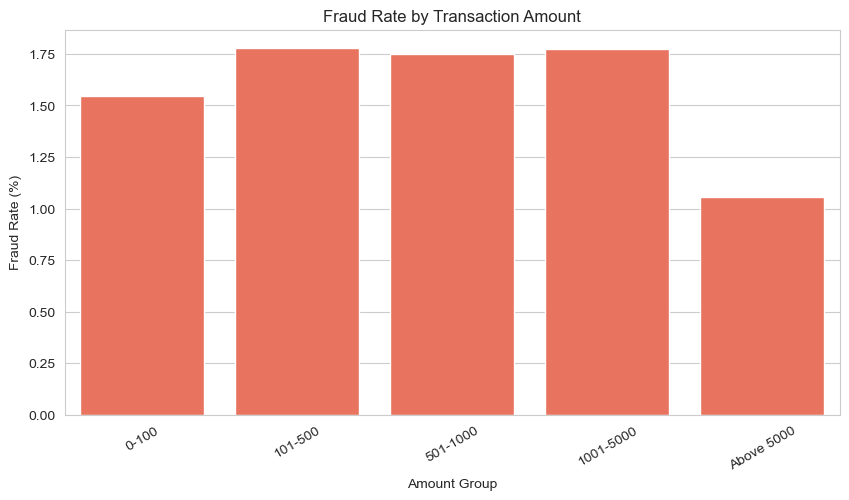

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=amount_analysis,x="amount_group",y="fraud_rate_percent",color="tomato")
plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Amount Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [13]:
device_analysis = (df.dropna(subset=["device_type"]).groupby("device_type")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
device_analysis["mean"] = device_analysis["mean"] * 100
device_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
device_analysis.sort_values("fraud_rate_percent",ascending=False)

,device_type,total_transactions,fraud_transactions,fraud_rate_percent
2,mac,8437,172,2.038639
3,other,8551,169,1.976377
4,windows,8831,166,1.879742
0,android,8566,153,1.786131
1,ios,8622,153,1.774530


In [14]:
transaction_type_analysis = (df.dropna(subset=["transaction_type"]).groupby("transaction_type")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
transaction_type_analysis["mean"] *= 100
transaction_type_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
transaction_type_analysis.sort_values("fraud_rate_percent",ascending=False)

,transaction_type,total_transactions,fraud_transactions,fraud_rate_percent
4,deposit,4148,79,1.904532
7,withdrawal,3771,63,1.670644
2,cash_out,2893,46,1.590045
0,bill_payment,6933,107,1.543343
6,transfer,6707,100,1.490980
5,purchase,3957,57,1.440485
1,cash_in,2906,38,1.307639
3,debit,2879,28,0.972560


In [15]:
new_device_analysis = (df.dropna(subset=["new_device"]).groupby("new_device")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
new_device_analysis["mean"] *= 100
new_device_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
new_device_analysis

,new_device,total_transactions,fraud_transactions,fraud_rate_percent
0,0.0,17868,286,1.600627
1,1.0,1672,47,2.811005


In [16]:
new_location_analysis = (df.dropna(subset=["new_location"]).groupby("new_location")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
new_location_analysis["mean"] *= 100
new_location_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
new_location_analysis

,new_location,total_transactions,fraud_transactions,fraud_rate_percent
0,0.0,17224,268,1.555968
1,1.0,2316,65,2.806563


In [17]:
international_analysis = (df.dropna(subset=["is_international"]).groupby("is_international")["is_fraud"].agg(["count", "sum", "mean"]).reset_index())
international_analysis["mean"] *= 100
international_analysis.rename(columns={"count": "total_transactions","sum": "fraud_transactions","mean": "fraud_rate_percent"}, inplace=True)
international_analysis

,is_international,total_transactions,fraud_transactions,fraud_rate_percent
0,0.0,10334,98,0.948326
1,1.0,1392,24,1.724138


In [18]:
df["risk_score"] = pd.to_numeric(df["risk_score"],errors="coerce")
risk_comparison = (df.groupby("is_fraud")["risk_score"].mean().reset_index())
risk_comparison["transaction_status"] = risk_comparison["is_fraud"].map({0: "Normal",1: "Fraud"})
risk_comparison

,is_fraud,risk_score,transaction_status
0,0,24.097347,Normal
1,1,32.688377,Fraud


In [19]:
behavior_columns = [
    "transactions_last_24h",
    "transactions_last_1h",
    "login_attempts",
    "failed_payment_attempts",
    "distance_from_home_km",
    "average_amount_30d",
    "risk_score"
]

available_columns = [
    column for column in behavior_columns
    if column in df.columns
]

behavior_summary = (
    df.groupby("is_fraud")[available_columns]
      .mean()
      .round(2)
)

behavior_summary

,transactions_last_24h,transactions_last_1h,login_attempts,failed_payment_attempts,distance_from_home_km,average_amount_30d,risk_score
is_fraud,,,,,,,
0,4.15,2.99,1.84,1.48,13.39,178.95,24.10
1,4.34,3.64,1.98,1.78,13.85,188.84,32.69


In [20]:
total_transactions = len(df)
total_fraud = df["is_fraud"].sum()
fraud_rate = (total_fraud / total_transactions) * 100
peak_hour = hourly_fraud.loc[hourly_fraud["is_fraud"].idxmax(),"transaction_hour"]
peak_day = daily_fraud.loc[daily_fraud["is_fraud"].idxmax(),"day_name"]

print("TEMPORAL AND BEHAVIORAL FRAUD ANALYSIS")
print("--------------------------------------")
print("Total transactions:", total_transactions)
print("Fraud transactions:", total_fraud)
print("Overall fraud rate:", round(fraud_rate, 2), "%")
print("Hour with the highest fraud count:", peak_hour)
print("Day with the highest fraud count:", peak_day)

TEMPORAL AND BEHAVIORAL FRAUD ANALYSIS
--------------------------------------
Total transactions: 57661
Fraud transactions: 998
Overall fraud rate: 1.73 %
Hour with the highest fraud count: 7
Day with the highest fraud count: Monday
